<a href="https://colab.research.google.com/github/MExavierx/projeto-pnad-inclusao-digital/blob/main/Exclus%C3%A3o_Digital_no_Brasil_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bem-vindo(a)!

Este notebook tem como objetivo realizar a análise exploratória de três tabelas da PNAD Contínua (IBGE), buscando compreender os fatores relacionados ao acesso e ao uso da internet no Brasil.

As tabelas analisadas são:

* **Tabela 9661:** Pessoas de 10 anos ou mais que não utilizaram a Internet, por motivo da não utilização (inclui Unidades da Federação);
* **Tabela 7414:** Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio;
* **Tabela 9670:** Pessoas que utilizaram a Internet, por nível de instrução e frequência de utilização.

A partir desses dados, este projeto busca responder à seguinte pergunta norteadora:

> **Como renda, escolaridade e motivos para a não utilização da internet se relacionam com o acesso e o uso da internet nos estados brasileiros?**

## Ferramentas utilizadas

* Python
* Pandas
* Matplotlib
* Google Colab



## Pergunta norteadora

> Como renda, escolaridade e motivos para a não utilização da internet se relacionam com o acesso e o uso da internet nos estados brasileiros?

## Etapas da análise

1. Importação das bibliotecas.
2. Carregamento das bases de dados.
3. Limpeza e tratamento dos dados.
4. Análise exploratória dos dados (EDA).
5. Visualização dos resultados.
6. Principais insights e conclusões.

#Importação de bibliotecas e leitura das tabelas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mat


df_renda = pd.read_excel("/content/Renda.xlsx")
df_escolaridade = pd.read_excel("/content/Escolaridade..xlsx")
df_motivos = pd.read_excel("/content/Motivos.xlsx")

#Carregamento da base de dados

Verificando quantas linhas e colunas a nossa tabela renda tem

In [ ]:
df_renda.shape

(23, 5)

Verificando as informações da nossa tabela escolhida, como por exemplo: linhas e colunas, o tipo dado que consta nas nossas colunas - object, int ou float - desse caso a tabela escolhida é renda

In [ ]:
df_renda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                           --------------  ----- 
 0   Tabela 7414 - Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio  9 non-null      object
 1   Unnamed: 1                                                                                                                                       19 non-null     object
 2   Unnamed: 2                                                                                                                                       21 non-null     object
 3   Unnamed: 3                  

Visualizando as primeiras 10 linhas

In [ ]:
df_renda.head(10)

,"Tabela 7414 - Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Variável - Rendimento médio mensal real domici...,NaN,NaN,NaN,NaN
1,Brasil e Grande Região,Existência de utilização da Internet no domicílio,Ano x Situação do domicílio,NaN,NaN
2,NaN,NaN,2025,NaN,NaN
3,NaN,NaN,Total,Urbana,Rural
4,Brasil,Total,2280,2420,1242
5,NaN,Havia utilização de internet,2312,2446,1255
6,NaN,Não havia utilização de internet,1316,1412,1102
7,Norte,Total,1586,1727,990
8,NaN,Havia utilização de internet,1619,1741,1028
9,NaN,Não havia utilização de internet,901,1109,767


Visualizando as 10 últimas linhas

In [ ]:
df_renda.tail(10)

,"Tabela 7414 - Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
13,Sudeste,Total,2687,2748,1616
14,NaN,Havia utilização de internet,2716,2776,1628
15,NaN,Não havia utilização de internet,1535,1552,1436
16,Sul,Total,2761,2851,2056
17,NaN,Havia utilização de internet,2787,2875,2075
18,NaN,Não havia utilização de internet,1779,1797,1724
19,Centro-Oeste,Total,2699,2756,1911
20,NaN,Havia utilização de internet,2718,2776,1905
21,NaN,Não havia utilização de internet,1700,1654,2114
22,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN


Dia 21/07 - voltando a fazer o tratamento dos dados, vamos imprimir as 10 primeiras e a informação da tabela, usando o .head(10) e o .info()

In [ ]:
df_renda.head(10)

,"Tabela 7414 - Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Variável - Rendimento médio mensal real domici...,NaN,NaN,NaN,NaN
1,Brasil e Grande Região,Existência de utilização da Internet no domicílio,Ano x Situação do domicílio,NaN,NaN
2,NaN,NaN,2025,NaN,NaN
3,NaN,NaN,Total,Urbana,Rural
4,Brasil,Total,2280,2420,1242
5,NaN,Havia utilização de internet,2312,2446,1255
6,NaN,Não havia utilização de internet,1316,1412,1102
7,Norte,Total,1586,1727,990
8,NaN,Havia utilização de internet,1619,1741,1028
9,NaN,Não havia utilização de internet,901,1109,767


In [ ]:
df_renda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                           --------------  ----- 
 0   Tabela 7414 - Rendimento médio mensal real domiciliar per capita, por situação do domicílio e existência de utilização da Internet no domicílio  9 non-null      object
 1   Unnamed: 1                                                                                                                                       19 non-null     object
 2   Unnamed: 2                                                                                                                                       21 non-null     object
 3   Unnamed: 3                  

#Verificamos que com o comando .head(), temos elementos adicionados como NaN e visualizando com .info(), podemos ver que todas as colunas são object, enquanto deveriam ser int. Vamos modificar isso mais pra frente.

Primeiro, irei transformar a linha 4 como o header do nosso df

In [ ]:
df_renda = pd.read_excel("/content/Renda.xlsx", header=4)

In [ ]:
df_renda.head()

,Unnamed: 0,Unnamed: 1,Total,Urbana,Rural
0,Brasil,Total,2280.0,2420.0,1242.0
1,NaN,Havia utilização de internet,2312.0,2446.0,1255.0
2,NaN,Não havia utilização de internet,1316.0,1412.0,1102.0
3,Norte,Total,1586.0,1727.0,990.0
4,NaN,Havia utilização de internet,1619.0,1741.0,1028.0


Renomeando as colunas (Unnamed: 0) e (Unnamed:1), como "Região" e "Situação"

In [ ]:
df_renda = df_renda.rename(columns={
    "Unnamed: 0": "Região",
    "Unnamed: 1": "Situação"
})

In [ ]:
df_renda.head()

,Região,Situação,Total,Urbana,Rural
0,Brasil,Total,2280.0,2420.0,1242.0
1,NaN,Havia utilização de internet,2312.0,2446.0,1255.0
2,NaN,Não havia utilização de internet,1316.0,1412.0,1102.0
3,Norte,Total,1586.0,1727.0,990.0
4,NaN,Havia utilização de internet,1619.0,1741.0,1028.0


Preenchendo valores NaN da coluna "Região"

In [ ]:
df_renda['Região'] = df_renda["Região"].ffill()

In [ ]:
df_renda.head(10)

,Região,Situação,Total,Urbana,Rural
0,Brasil,Total,2280.0,2420.0,1242.0
1,Brasil,Havia utilização de internet,2312.0,2446.0,1255.0
2,Brasil,Não havia utilização de internet,1316.0,1412.0,1102.0
3,Norte,Total,1586.0,1727.0,990.0
4,Norte,Havia utilização de internet,1619.0,1741.0,1028.0
5,Norte,Não havia utilização de internet,901.0,1109.0,767.0
6,Nordeste,Total,1483.0,1650.0,872.0
7,Nordeste,Havia utilização de internet,1503.0,1670.0,858.0
8,Nordeste,Não havia utilização de internet,1073.0,1108.0,1023.0
9,Sudeste,Total,2687.0,2748.0,1616.0


In [ ]:
df_renda.head()

,Região,Situação,Total,Urbana,Rural
0,Brasil,Total,2280.0,2420.0,1242.0
1,Brasil,Havia utilização de internet,2312.0,2446.0,1255.0
2,Brasil,Não havia utilização de internet,1316.0,1412.0,1102.0
3,Norte,Total,1586.0,1727.0,990.0
4,Norte,Havia utilização de internet,1619.0,1741.0,1028.0


In [ ]:
df_renda.tail()

,Região,Situação,Total,Urbana,Rural
14,Sul,Não havia utilização de internet,1779.0,1797.0,1724.0
15,Centro-Oeste,Total,2699.0,2756.0,1911.0
16,Centro-Oeste,Havia utilização de internet,2718.0,2776.0,1905.0
17,Centro-Oeste,Não havia utilização de internet,1700.0,1654.0,2114.0
18,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN


Apagando a linha 18 que consta a fonte, para que não afete nosso EDA.

In [ ]:
df_renda = df_renda.drop(index=18)

In [ ]:
df_renda.tail()

,Região,Situação,Total,Urbana,Rural
13,Sul,Havia utilização de internet,2787.0,2875.0,2075.0
14,Sul,Não havia utilização de internet,1779.0,1797.0,1724.0
15,Centro-Oeste,Total,2699.0,2756.0,1911.0
16,Centro-Oeste,Havia utilização de internet,2718.0,2776.0,1905.0
17,Centro-Oeste,Não havia utilização de internet,1700.0,1654.0,2114.0


Vamos tratar a tabela Escolaridade agora. Repetindo os mesmos processos do df anterior

In [ ]:
df_escolaridade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 10 columns):
 #   Column                                                                                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                                                                                      --------------  ----- 
 0   Tabela 9670 - Pessoas de 10 anos ou mais de idade que utilizaram a Internet no período de referência dos últimos três meses, por nível de instrução e frequência de utilização da internet  9 non-null      object
 1   Unnamed: 1                                                                                                                                                                                  31 non-null     object
 2   Unnamed: 2                  

In [ ]:
df_escolaridade.shape

(35, 10)

In [ ]:
df_escolaridade.head()

,"Tabela 9670 - Pessoas de 10 anos ou mais de idade que utilizaram a Internet no período de referência dos últimos três meses, por nível de instrução e frequência de utilização da internet",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Variável - Pessoas de 10 anos ou mais de idade...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Brasil e Grande Região,Frequência de utilização da internet,Ano x Nível de instrução,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
4,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491


In [ ]:
df_escolaridade.tail()

,"Tabela 9670 - Pessoas de 10 anos ou mais de idade que utilizaram a Internet no período de referência dos últimos três meses, por nível de instrução e frequência de utilização da internet",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
30,NaN,Todos os dias,13493,254,3258,932,1147,4129,867,2906
31,NaN,5 ou 6 vezes por semana,156,9,65,13,10,36,5,18
32,NaN,De 1 a 4 vezes por semana,206,18,117,14,12,30,2,13
33,NaN,Menos de uma vez por semana,52,6,23,4,3,11,1,5
34,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Alterando nosso cabeçalho.

In [ ]:
df_escolaridade = pd.read_excel("/content/Escolaridade..xlsx", header=2)

In [ ]:
df_escolaridade.head()

,Brasil e Grande Região,Frequência de utilização da internet,Ano x Nível de instrução,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
2,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491
3,NaN,Todos os dias,161231,3049,40630,12042,12580,52698,9318,30913
4,NaN,5 ou 6 vezes por semana,3108,175,1322,260,185,756,70,340


Renomeando os Unnameds pelos seus nomes da tabela original.

In [ ]:
df_escolaridade = df_escolaridade.rename(columns={
    "Ano x Nível de instrução": "Total",
    "Unnamed: 3": "Sem instrução",
    "Unnamed: 4": "Fundamental incompleto",
    "Unnamed: 5": "Fundamental completo",
    "Unnamed: 6": "Médio incompleto",
    "Unnamed: 7": "Médio completo",
    "Unnamed: 8": "Superior incompleto",
    "Unnamed: 9": "Superior completo"
})

In [ ]:
df_escolaridade.head()

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
0,NaN,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
2,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491
3,NaN,Todos os dias,161231,3049,40630,12042,12580,52698,9318,30913
4,NaN,5 ou 6 vezes por semana,3108,175,1322,260,185,756,70,340


Apagando as linhas que foram adicionadas erroneamente, sendo elas a linha 0 e a linha 1.

In [ ]:
df_escolaridade = df_escolaridade.drop(index=[0,1])

In [ ]:
df_escolaridade.head()

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
2,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491
3,NaN,Todos os dias,161231,3049,40630,12042,12580,52698,9318,30913
4,NaN,5 ou 6 vezes por semana,3108,175,1322,260,185,756,70,340
5,NaN,De 1 a 4 vezes por semana,3525,298,1959,282,152,596,52,187
6,NaN,Menos de uma vez por semana,872,121,448,71,39,130,10,51


In [ ]:
df_escolaridade.tail()

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
28,NaN,Todos os dias,13493,254,3258,932,1147,4129,867,2906
29,NaN,5 ou 6 vezes por semana,156,9,65,13,10,36,5,18
30,NaN,De 1 a 4 vezes por semana,206,18,117,14,12,30,2,13
31,NaN,Menos de uma vez por semana,52,6,23,4,3,11,1,5
32,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Apagando a linha 32, que pode alterar a nossa leitura mais pra frente.

In [ ]:
df_escolaridade = df_escolaridade.drop(index=32)

In [ ]:
df_escolaridade.tail()

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
27,Centro-Oeste,Total,13908,287,3462,963,1172,4205,875,2943
28,NaN,Todos os dias,13493,254,3258,932,1147,4129,867,2906
29,NaN,5 ou 6 vezes por semana,156,9,65,13,10,36,5,18
30,NaN,De 1 a 4 vezes por semana,206,18,117,14,12,30,2,13
31,NaN,Menos de uma vez por semana,52,6,23,4,3,11,1,5


Realizando o .ffill() na coluna "Brasil e Grande Região" no df_escolaridade.

In [ ]:
df_escolaridade["Brasil e Grande Região"] = (
    df_escolaridade["Brasil e Grande Região"].ffill()
)

In [ ]:
df_escolaridade.head(15)

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
2,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491
3,Brasil,Todos os dias,161231,3049,40630,12042,12580,52698,9318,30913
4,Brasil,5 ou 6 vezes por semana,3108,175,1322,260,185,756,70,340
5,Brasil,De 1 a 4 vezes por semana,3525,298,1959,282,152,596,52,187
6,Brasil,Menos de uma vez por semana,872,121,448,71,39,130,10,51
7,Norte,Total,13988,370,4048,1052,1256,4558,790,1914
8,Norte,Todos os dias,12954,288,3520,963,1179,4360,775,1867
9,Norte,5 ou 6 vezes por semana,475,24,203,43,42,120,10,33
10,Norte,De 1 a 4 vezes por semana,448,36,260,38,29,66,4,14
11,Norte,Menos de uma vez por semana,112,22,64,7,6,11,0,1


Tratando a tabela Motivos

In [ ]:
df_motivos.shape

(38, 9)

In [ ]:
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 9 columns):
 #   Column                                                                                                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                      --------------  ----- 
 0   Tabela 9661 - Pessoas de 10 anos ou mais de idade que não utilizaram Internet no período de referência dos últimos três meses, por motivo de não terem utilizado a internet (inclui UF) (a partir de 2022)  36 non-null     object
 1   Unnamed: 1                                                                                                                                                                                           

In [ ]:
df_motivos.head()

,"Tabela 9661 - Pessoas de 10 anos ou mais de idade que não utilizaram Internet no período de referência dos últimos três meses, por motivo de não terem utilizado a internet (inclui UF) (a partir de 2022)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Variável - Pessoas de 10 anos ou mais de idade...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região e Unidade da Federação",Ano x Motivo de não terem utilizado a internet,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Total,Serviço de acesso à Internet ou equipamento el...,Serviço de acesso à Internet não estava dispon...,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
4,Brasil,17697,1600,312,4923,806,7953,935,1168


In [ ]:
df_motivos.tail()

,"Tabela 9661 - Pessoas de 10 anos ou mais de idade que não utilizaram Internet no período de referência dos últimos três meses, por motivo de não terem utilizado a internet (inclui UF) (a partir de 2022)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
33,Mato Grosso do Sul,266,10,4,125,15,82,17,14
34,Mato Grosso,235,26,14,68,18,64,22,22
35,Goiás,364,25,5,83,5,185,38,24
36,Distrito Federal,85,7,0,12,3,39,14,11
37,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Alterando o nosso cabeçalho novamente.

In [ ]:
#df_escolaridade = pd.read_excel("/content/Escolaridade..xlsx", header=2)
df_motivos = pd .read_excel("/content/Motivos.xlsx", header=2)

In [ ]:
df_motivos.head()

,"Brasil, Grande Região e Unidade da Federação",Ano x Motivo de não terem utilizado a internet,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Total,Serviço de acesso à Internet ou equipamento el...,Serviço de acesso à Internet não estava dispon...,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
2,Brasil,17697,1600,312,4923,806,7953,935,1168
3,Norte,1615,291,51,455,54,579,99,85
4,Nordeste,5695,625,80,1163,84,3154,251,338


Renomeando algumas colunas Unnameds.

In [ ]:
df_motivos = df_motivos.rename(columns={
    "Ano x Motivo de não terem utilizado a internet": "Total",
    "Unnamed: 2": "Serviço de acesso à Internet ou equipamento eletrônico necessário era caro",
    "Unnamed: 3": "Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar",
    "Unnamed: 4": "Falta de necessidade",
    "Unnamed: 5": "Falta de tempo",
    "Unnamed: 6": "Não sabiam utilizar a internet",
    "Unnamed: 7": "Preocupação com privacidade ou segurança",
    "Unnamed: 8": "Outro motivo"
})

In [ ]:
df_motivos.head()

,"Brasil, Grande Região e Unidade da Federação",Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
0,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Total,Serviço de acesso à Internet ou equipamento el...,Serviço de acesso à Internet não estava dispon...,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
2,Brasil,17697,1600,312,4923,806,7953,935,1168
3,Norte,1615,291,51,455,54,579,99,85
4,Nordeste,5695,625,80,1163,84,3154,251,338


Apagando a linha 0 e 1 que nesse caso não tem utilidade para nossa análise.

In [ ]:
df_motivos = df_motivos.drop(index=[0,1])

In [ ]:
df_motivos.head()

,"Brasil, Grande Região e Unidade da Federação",Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
2,Brasil,17697,1600,312,4923,806,7953,935,1168
3,Norte,1615,291,51,455,54,579,99,85
4,Nordeste,5695,625,80,1163,84,3154,251,338
5,Sudeste,7161,450,121,2293,520,2863,374,538
6,Sul,2277,168,36,724,108,987,120,135


In [ ]:
df_motivos.tail()


,"Brasil, Grande Região e Unidade da Federação",Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
31,Mato Grosso do Sul,266,10,4,125,15,82,17,14
32,Mato Grosso,235,26,14,68,18,64,22,22
33,Goiás,364,25,5,83,5,185,38,24
34,Distrito Federal,85,7,0,12,3,39,14,11
35,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_motivos = df_motivos.drop(index=[34])

In [ ]:
df_motivos.tail()

,"Brasil, Grande Região e Unidade da Federação",Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
30,Rio Grande do Sul,759,57,8,207,13,416,31,28
31,Mato Grosso do Sul,266,10,4,125,15,82,17,14
32,Mato Grosso,235,26,14,68,18,64,22,22
33,Goiás,364,25,5,83,5,185,38,24
35,Fonte: IBGE - Pesquisa Nacional por Amostra de...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vamos verificar os tipos de dados de cada tabela:


In [ ]:
df_renda.head()

,Região,Situação,Total,Urbana,Rural
0,Brasil,Total,2280.0,2420.0,1242.0
1,Brasil,Havia utilização de internet,2312.0,2446.0,1255.0
2,Brasil,Não havia utilização de internet,1316.0,1412.0,1102.0
3,Norte,Total,1586.0,1727.0,990.0
4,Norte,Havia utilização de internet,1619.0,1741.0,1028.0


Com o info vemos como está distruibuido cada tipo de dado.

In [ ]:
df_renda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Região    18 non-null     object 
 1   Situação  18 non-null     object 
 2   Total     18 non-null     float64
 3   Urbana    18 non-null     float64
 4   Rural     18 non-null     float64
dtypes: float64(3), object(2)
memory usage: 852.0+ bytes


In [ ]:
df_escolaridade.head()

,Brasil e Grande Região,Frequência de utilização da internet,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
2,Brasil,Total,168736,3643,44360,12655,12956,54181,9450,31491
3,Brasil,Todos os dias,161231,3049,40630,12042,12580,52698,9318,30913
4,Brasil,5 ou 6 vezes por semana,3108,175,1322,260,185,756,70,340
5,Brasil,De 1 a 4 vezes por semana,3525,298,1959,282,152,596,52,187
6,Brasil,Menos de uma vez por semana,872,121,448,71,39,130,10,51


Nesse caso com o .info(), vemos que os tipos de dados estão sendo interpredados de forma errada, já que há elementos em diversas colunas que são int e não object.

In [ ]:
df_escolaridade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 2 to 31
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Brasil e Grande Região                30 non-null     object
 1   Frequência de utilização da internet  30 non-null     object
 2   Total                                 30 non-null     object
 3   Sem instrução                         30 non-null     object
 4   Fundamental incompleto                30 non-null     object
 5   Fundamental completo                  30 non-null     object
 6   Médio incompleto                      30 non-null     object
 7   Médio completo                        30 non-null     object
 8   Superior incompleto                   30 non-null     object
 9   Superior completo                     30 non-null     object
dtypes: object(10)
memory usage: 2.5+ KB


#Analisando onde está o problema:

Utilizo o .map(type) para identificar o tipo de dado de cada elemento presente na coluna "Total". Em seguida, o .value_counts() contabiliza quantas vezes cada tipo de dado aparece nessa coluna.

In [ ]:
df_escolaridade["Total"].map(type).value_counts()

,count
Total,
<class 'int'>,30


Como vimos, todos os elementos são vistos como Int64, mas utilizando o info vemos que ele consta como object. Precisamos continuar analisando.

repr(objeto) mostra a representação interna do objeto, exatamente como o Python o interpreta. É útil para verificar detalhes como aspas, caracteres especiais (\n, \t) ou confirmar se um número está armazenado como texto ('168736') ou como inteiro (168736).

In [ ]:
repr(df_escolaridade["Total"].iloc[0])

'168736'

In [ ]:
df_escolaridade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 2 to 31
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Brasil e Grande Região                30 non-null     object
 1   Frequência de utilização da internet  30 non-null     object
 2   Total                                 30 non-null     object
 3   Sem instrução                         30 non-null     object
 4   Fundamental incompleto                30 non-null     object
 5   Fundamental completo                  30 non-null     object
 6   Médio incompleto                      30 non-null     object
 7   Médio completo                        30 non-null     object
 8   Superior incompleto                   30 non-null     object
 9   Superior completo                     30 non-null     object
dtypes: object(10)
memory usage: 2.5+ KB


Vamos converter para o tipo inteiro `(int)` as colunas que possuem apenas valores numéricos, mas que ainda estão armazenadas como object. Primeiro, criamos uma lista chamada colunas_numericas, contendo o nome de todas as colunas que desejamos converter. Em seguida, selecionamos essas colunas no DataFrame e utilizamos o método `.astype(int)` para alterar o tipo de seus dados para inteiro `(int)`, substituindo as colunas originais pelas novas convertidas.

In [ ]:
colunas_numericas = [
    "Total",
    "Sem instrução",
    "Fundamental incompleto",
    "Fundamental completo",
    "Médio incompleto",
    "Médio completo",
    "Superior incompleto",
    "Superior completo"
]

df_escolaridade[colunas_numericas] = (
    df_escolaridade[colunas_numericas]
    .astype(int)
)

Verificando se deu certo.

In [ ]:
df_escolaridade.dtypes

,0
Brasil e Grande Região,object
Frequência de utilização da internet,object
Total,int64
Sem instrução,int64
Fundamental incompleto,int64
Fundamental completo,int64
Médio incompleto,int64
Médio completo,int64
Superior incompleto,int64
Superior completo,int64


Analisando a tabela Motivos.

In [ ]:
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2 to 35
Data columns (total 9 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Brasil, Grande Região e Unidade da Federação                                             33 non-null     object
 1   Total                                                                                    32 non-null     object
 2   Serviço de acesso à Internet ou equipamento eletrônico necessário era caro               32 non-null     object
 3   Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar  32 non-null     object
 4   Falta de necessidade                                                                     32 non-null     object
 5   Falta de tempo                                                                 

Percebe-se que o df_motivos tem o mesmo "defeito" encontrado no df anterior.

In [ ]:
df_motivos.head()

,"Brasil, Grande Região e Unidade da Federação",Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
2,Brasil,17697,1600,312,4923,806,7953,935,1168
3,Norte,1615,291,51,455,54,579,99,85
4,Nordeste,5695,625,80,1163,84,3154,251,338
5,Sudeste,7161,450,121,2293,520,2863,374,538
6,Sul,2277,168,36,724,108,987,120,135


Vamos realizar o mesmo processo.

In [ ]:
df_motivos["Total"].map(type).value_counts()

,count
Total,
<class 'int'>,32
<class 'float'>,1


In [ ]:
repr(df_motivos["Total"].iloc[0])

'17697'

In [ ]:
df_motivos = df_motivos.drop(index=35)

In [ ]:
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 2 to 33
Data columns (total 9 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Brasil, Grande Região e Unidade da Federação                                             32 non-null     object
 1   Total                                                                                    32 non-null     object
 2   Serviço de acesso à Internet ou equipamento eletrônico necessário era caro               32 non-null     object
 3   Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar  32 non-null     object
 4   Falta de necessidade                                                                     32 non-null     object
 5   Falta de tempo                                                                 

In [ ]:
colunas_numericas = [
    "Total",
    "Serviço de acesso à Internet ou equipamento eletrônico necessário era caro",
    "Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar",
    "Falta de necessidade",
    "Não sabiam utilizar a internet",
    "Preocupação com privacidade ou segurança",
    "Outro motivo"
    ]

df_motivos[colunas_numericas] = (
    df_motivos[colunas_numericas]
    .astype(int)
)

In [ ]:
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 2 to 33
Data columns (total 9 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Brasil, Grande Região e Unidade da Federação                                             32 non-null     object
 1   Total                                                                                    32 non-null     int64 
 2   Serviço de acesso à Internet ou equipamento eletrônico necessário era caro               32 non-null     int64 
 3   Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar  32 non-null     int64 
 4   Falta de necessidade                                                                     32 non-null     int64 
 5   Falta de tempo                                                                 

A coluna "Falta de tempo" continua definida com os dados do tipo object, precisamos tratar só ela.

In [ ]:
df_motivos["Falta de tempo"]

,Falta de tempo
2,806
3,54
4,84
5,520
6,108
7,40
8,3
9,5
10,13
11,1


In [ ]:
df_motivos["Falta de tempo"].map(type).value_counts()

,count
Falta de tempo,
<class 'int'>,32


Verificando quais são os elementos que tem dentro da coluna de forma única em formato de array.

In [ ]:
df_motivos["Falta de tempo"].unique()

array([806, 54, 84, 520, 108, 40, 3, 5, 13, 1, 24, 0, 9, 18, 4, 15, 2, 73,
       425, 65, 30], dtype=object)

In [ ]:
for valor in df_motivos["Falta de tempo"].unique():
  print(repr(valor))

806
54
84
520
108
40
3
5
13
1
24
0
9
18
4
15
2
73
425
65
30


Selecionamos a coluna "Falta de tempo" e utilizamos o atributo .dtype para verificar qual é o tipo de dado armazenado nela. Em seguida, usamos print() para exibir essa informação na tela. Com o .info() visualizamos o resumo do df e com o .columns.tolist() acessamos os nomes das colunas do DataFrame e tranformamos em lista.

In [ ]:
print(df_motivos["Falta de tempo"].dtype)

df_motivos.info()

df_motivos.columns.tolist()

object
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 2 to 33
Data columns (total 9 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Brasil, Grande Região e Unidade da Federação                                             32 non-null     object
 1   Total                                                                                    32 non-null     int64 
 2   Serviço de acesso à Internet ou equipamento eletrônico necessário era caro               32 non-null     int64 
 3   Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar  32 non-null     int64 
 4   Falta de necessidade                                                                     32 non-null     int64 
 5   Falta de tempo                                                          

['Brasil, Grande Região e Unidade da Federação',
 'Total',
 'Serviço de acesso à Internet ou equipamento eletrônico necessário era caro',
 'Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar',
 'Falta de necessidade',
 'Falta de tempo',
 'Não sabiam utilizar a internet',
 'Preocupação com privacidade ou segurança',
 'Outro motivo']

Selecionamos a coluna "Falta de tempo" e utilizamos a função pd.to_numeric() para converter seus valores para o tipo numérico. Em seguida, atribuímos o resultado de volta à mesma coluna, atualizando os dados no DataFrame.

In [ ]:
df_motivos["Falta de tempo"] = pd.to_numeric(df_motivos["Falta de tempo"])

In [ ]:
df_motivos["Falta de tempo"].dtype

dtype('int64')

In [ ]:
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 2 to 33
Data columns (total 9 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Brasil, Grande Região e Unidade da Federação                                             32 non-null     object
 1   Total                                                                                    32 non-null     int64 
 2   Serviço de acesso à Internet ou equipamento eletrônico necessário era caro               32 non-null     int64 
 3   Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar  32 non-null     int64 
 4   Falta de necessidade                                                                     32 non-null     int64 
 5   Falta de tempo                                                                 

Dia 29/07 - Começando a EDA

In [ ]:
df_escolaridade.info()
df_renda.info()
df_motivos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 2 to 31
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Brasil e Grande Região                30 non-null     object
 1   Frequência de utilização da internet  30 non-null     object
 2   Total                                 30 non-null     int64 
 3   Sem instrução                         30 non-null     int64 
 4   Fundamental incompleto                30 non-null     int64 
 5   Fundamental completo                  30 non-null     int64 
 6   Médio incompleto                      30 non-null     int64 
 7   Médio completo                        30 non-null     int64 
 8   Superior incompleto                   30 non-null     int64 
 9   Superior completo                     30 non-null     int64 
dtypes: int64(8), object(2)
memory usage: 2.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 en

Utilizamos o método `.describe()` para visualizar um resumo estatístico das colunas numéricas do df_escolaridade. O resumo apresenta a quantidade de valores `(count)`, a média `(mean)`, o desvio padrão `(std)`, o valor mínimo `(min)`, os quartis `(25%, 50% e 75%)` e o valor máximo `(max)` de cada coluna.

In [ ]:
df_escolaridade.describe()

,Total,Sem instrução,Fundamental incompleto,Fundamental completo,Médio incompleto,Médio completo,Superior incompleto,Superior completo
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,22498.100000,485.633333,5914.600000,1687.300000,1727.433333,7224.133333,1259.966667,4198.866667
std,43474.461672,881.426723,11083.420381,3247.294483,3344.860542,14167.359355,2480.696947,8391.764295
min,52.000000,6.000000,23.000000,4.000000,3.000000,11.000000,0.000000,1.000000
25%,421.250000,24.000000,200.000000,38.000000,18.000000,64.500000,5.250000,25.250000
50%,1296.500000,136.500000,664.500000,114.000000,58.000000,309.000000,32.500000,142.500000
75%,21690.500000,331.750000,5502.250000,1826.750000,1664.750000,6712.750000,1388.000000,4561.500000
max,168736.000000,3643.000000,44360.000000,12655.000000,12956.000000,54181.000000,9450.000000,31491.000000


In [ ]:
df_renda.describe()

,Total,Urbana,Rural
count,18.000000,18.000000,18.000000
mean,1969.722222,2059.333333,1422.333333
std,644.770347,632.785346,464.281862
min,901.000000,1108.000000,767.000000
25%,1511.000000,1651.000000,1024.250000
50%,1739.500000,1769.000000,1345.500000
75%,2696.000000,2754.000000,1859.750000
max,2787.000000,2875.000000,2114.000000


In [ ]:
df_motivos.describe()

,Total,Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,Falta de necessidade,Falta de tempo,Não sabiam utilizar a internet,Preocupação com privacidade ou segurança,Outro motivo
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.00000,32.000000
mean,1656.500000,149.875000,29.125000,461.125000,75.500000,744.375000,87.25000,109.187500
std,3335.095588,296.404883,58.530251,943.464814,175.530532,1500.923775,174.04801,224.374031
min,41.000000,9.000000,0.000000,8.000000,0.000000,11.000000,2.00000,0.000000
25%,305.000000,23.500000,3.750000,66.750000,5.000000,125.250000,15.25000,13.500000
50%,619.500000,58.000000,10.500000,144.500000,14.000000,284.500000,35.00000,31.000000
75%,1170.500000,135.500000,25.500000,308.750000,43.500000,583.500000,72.25000,88.750000
max,17697.000000,1600.000000,312.000000,4923.000000,806.000000,7953.000000,935.00000,1168.000000


In [ ]:
df_escolaridade["Brasil e Grande Região"].unique()

array(['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste'],
      dtype=object)

In [ ]:
df_escolaridade["Frequência de utilização da internet"].unique()

array(['Total', 'Todos os dias', '5 ou 6 vezes por semana',
       'De 1 a 4 vezes por semana', 'Menos de uma vez por semana'],
      dtype=object)

In [ ]:
df_renda["Região"].unique()

array(['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste'],
      dtype=object)

In [ ]:
df_renda["Situação"].unique()

array(['Total', 'Havia utilização de internet',
       'Não havia utilização de internet'], dtype=object)

In [ ]:
df_escolaridade.isnull().sum()

,0
Brasil e Grande Região,0
Frequência de utilização da internet,0
Total,0
Sem instrução,0
Fundamental incompleto,0
Fundamental completo,0
Médio incompleto,0
Médio completo,0
Superior incompleto,0
Superior completo,0


In [ ]:
df_renda.isnull().sum()

,0
Região,0
Situação,0
Total,0
Urbana,0
Rural,0


In [ ]:
df_motivos.isnull().sum()

,0
"Brasil, Grande Região e Unidade da Federação",0
Total,0
Serviço de acesso à Internet ou equipamento eletrônico necessário era caro,0
Serviço de acesso à Internet não estava disponível nos locais que costumavam frequentar,0
Falta de necessidade,0
Falta de tempo,0
Não sabiam utilizar a internet,0
Preocupação com privacidade ou segurança,0
Outro motivo,0


In [ ]:
df_escolaridade.duplicated().sum()

np.int64(0)

In [ ]:
df_renda.duplicated().sum()

np.int64(0)

In [ ]:
df_motivos.duplicated().sum()

np.int64(0)

Respondendo algumas perguntas



> Adicionar aspas
Como renda, escolaridade e motivos para não utilizar a internet se relacionam com o acesso digital no Brasil?


Começando pelo df_escolaridade, vamos desenvolver a primeira pergunta:

🔎PERGUNTA 1: Como está distribuída a frequência de utilização da internet entre os diferentes níveis de escolaridade?



In [ ]:
df_long = df_escolaridade.melt(
    id_vars=[
        "Brasil e Grande Região",
        "Frequência de utilização da internet"
    ],
    var_name="Escolaridade",
    value_name="Quantidade"
)

In [ ]:
df_brasil = df_long[
    df_long["Brasil e Grande Região"] == "Brasil"
]

In [ ]:
df_brasil.head()

,Brasil e Grande Região,Frequência de utilização da internet,Escolaridade,Quantidade
0,Brasil,Total,Total,168736
1,Brasil,Todos os dias,Total,161231
2,Brasil,5 ou 6 vezes por semana,Total,3108
3,Brasil,De 1 a 4 vezes por semana,Total,3525
4,Brasil,Menos de uma vez por semana,Total,872


In [ ]:
tabela = df_brasil.pivot(
    index="Escolaridade",
    columns="Frequência de utilização da internet",
    values="Quantidade"
)

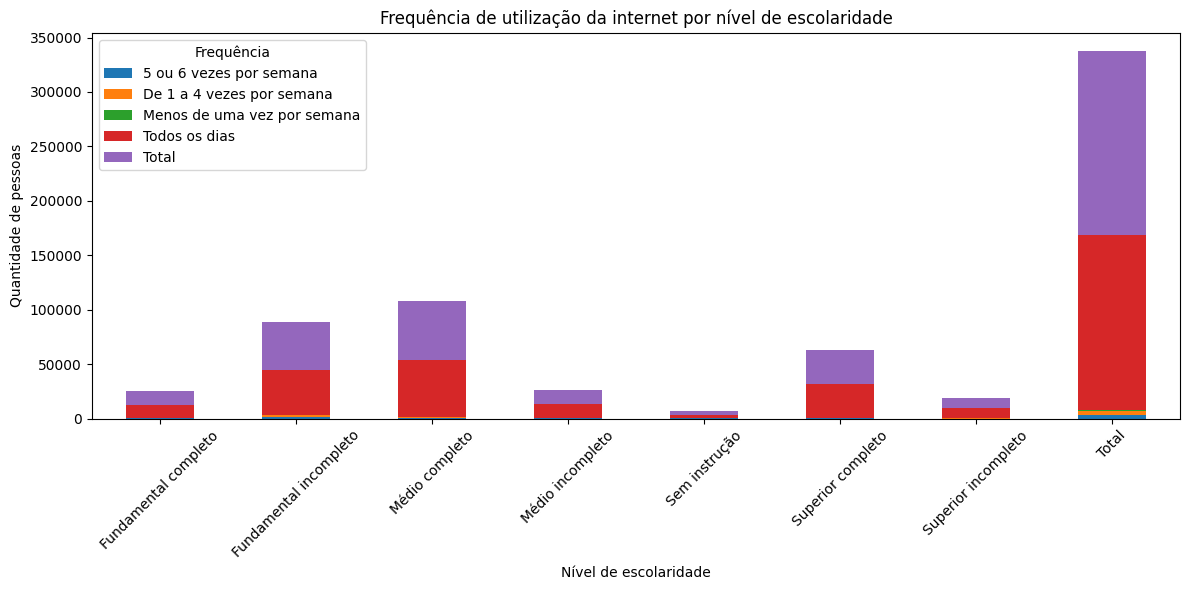

In [ ]:
import matplotlib.pyplot as mat

tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

mat.title("Frequência de utilização da internet por nível de escolaridade")
mat.xlabel("Nível de escolaridade")
mat.ylabel("Quantidade de pessoas")

mat.xticks(rotation=45)
mat.legend(title="Frequência")

mat.tight_layout()

mat.show()

Observa-se que a utilização diária da internet predomina em todos os níveis de escolaridade, enquanto as demais frequências apresentam menor representatividade. Entretanto, por se tratar de valores absolutos, este gráfico não permite concluir que a frequência de uso aumenta conforme a escolaridade. Ainda assim, os resultados destacam a relevância da internet no cotidiano e reforçam que a exclusão digital vai além do simples acesso à tecnologia.

🔎PERGUNTA 2: Existem diferenças regionais na utilização diária da internet entre os níveis de escolaridade?

In [ ]:
df_long2 = df_escolaridade.melt(
    id_vars=[
        "Brasil e Grande Região",
        "Frequência de utilização da internet"
    ],
    var_name="Escolaridade",
    value_name="Quantidade"
)

In [ ]:
df_diario = df_long2[
    df_long2["Frequência de utilização da internet"] == "Todos os dias"
]

In [ ]:
df_diario = df_diario[
    df_diario["Brasil e Grande Região"] != "Brasil"
]

In [ ]:
df_diario = df_diario[
    df_diario["Escolaridade"] != "Total"
]

In [ ]:
tabela2 = df_diario.pivot(
    index="Escolaridade",
    columns="Brasil e Grande Região",
    values="Quantidade"
)

In [ ]:
df_diario.head(15)

,Brasil e Grande Região,Frequência de utilização da internet,Escolaridade,Quantidade
36,Norte,Todos os dias,Sem instrução,288
41,Nordeste,Todos os dias,Sem instrução,1361
46,Sudeste,Todos os dias,Sem instrução,852
51,Sul,Todos os dias,Sem instrução,294
56,Centro-Oeste,Todos os dias,Sem instrução,254
66,Norte,Todos os dias,Fundamental incompleto,3520
71,Nordeste,Todos os dias,Fundamental incompleto,12601
76,Sudeste,Todos os dias,Fundamental incompleto,15264
81,Sul,Todos os dias,Fundamental incompleto,5987
86,Centro-Oeste,Todos os dias,Fundamental incompleto,3258


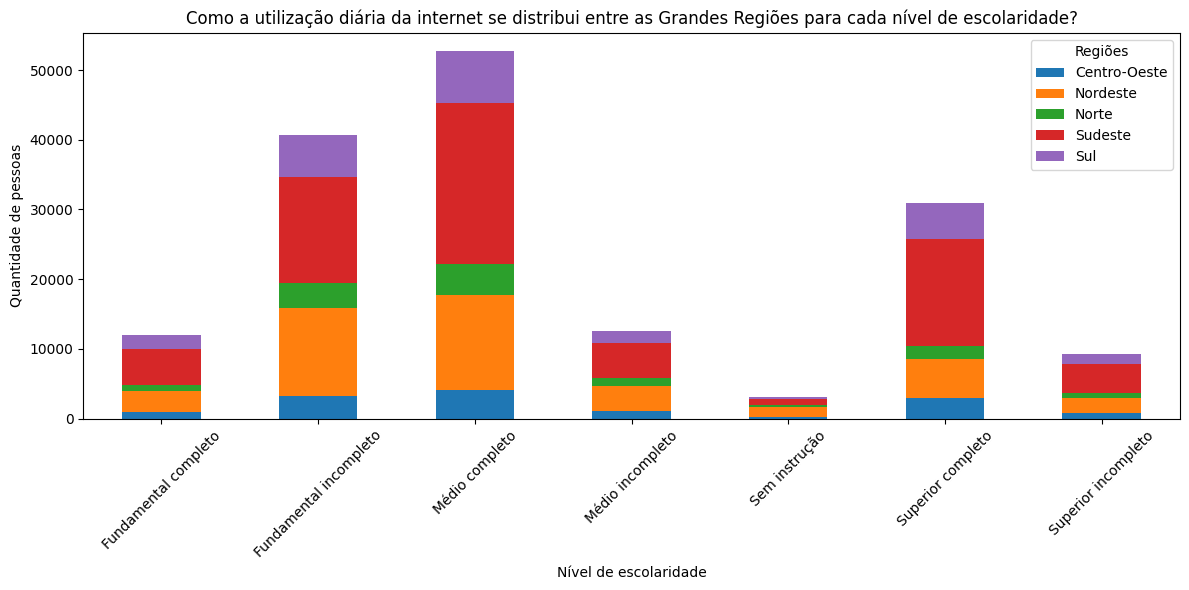

In [ ]:
import matplotlib.pyplot as mat

tabela2.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

mat.title("Como a utilização diária da internet se distribui entre as Grandes Regiões para cada nível de escolaridade?")
mat.xlabel("Nível de escolaridade")
mat.ylabel("Quantidade de pessoas")

mat.xticks(rotation=45)
mat.legend(title="Regiões")

mat.tight_layout()

mat.show()